In [98]:
import sys

sys.path.insert(0, '/home/caron/Bureau/Model/HexagonalScale/ST-GNN-for-wildifre-prediction/Prediction')

from GNN.tools import *

obj = read_object('temp.pkl', Path('./'))

obj

<xarray.Dataset>
Dimensions:                        (id: 6, date: 2394)
Coordinates:
    departement                    <U30 'departement-06-alpes-maritimes'
  * id                             (id) float64 0.0 1.0 2.0 3.0 4.0 5.0
  * date                           (date) object '2017-06-12' ... '2023-12-31'
    graph_id                       (id) float64 0.0 1.0 2.0 3.0 4.0 5.0
    latitude                       (id) float64 44.03 44.0 43.74 ... 43.88 44.22
    longitude                      (id) float64 7.067 7.542 ... 7.153 6.952
Data variables: (12/407)
    occurence                      (id, date) float64 0.0 0.0 0.0 ... 0.0 0.0
    burned_area                    (id, date) float64 0.0 0.0 0.0 ... 0.0 0.0
    time_intervention              (id, date) float64 0.0 0.0 0.0 ... 0.0 0.0
    influence                      (id, date) float64 0.0004181 ... 1.305e-16
    occurence_scale                (id, date) float64 0.0 0.0 0.0 ... 0.0 0.0
    influence_scale                (id, date) float64 0.05603 ... 9.397e-15
    ...                             ...
    NDWI_sum                       (id, date) float64 -25.51 -25.51 ... -4.712
    argile_landcover_mean          (id, date) float64 nan nan nan ... nan nan
    argile_landcover_min           (id, date) float64 nan nan nan ... nan nan
    argile_landcover_max           (id, date) float64 nan nan nan ... nan nan
    argile_landcover_std           (id, date) float64 nan nan nan ... nan nan
    argile_landcover_sum           (id, date) float64 nan nan nan ... nan nan

In [92]:
obj['occurence'].sum(dim=['date'])

<xarray.DataArray 'occurence' (id: 6)>
array([0.85820896, 0.41666667, 1.87218045, 0.89622642, 0.32121212,
       0.02777778])
Coordinates:
    departement  <U30 'departement-06-alpes-maritimes'
  * id           (id) float64 0.0 1.0 2.0 3.0 4.0 5.0
    graph_id     (id) float64 0.0 1.0 2.0 3.0 4.0 5.0
    latitude     (id) float64 44.03 44.0 43.74 43.75 43.88 44.22
    longitude    (id) float64 7.067 7.542 7.211 6.851 7.153 6.952

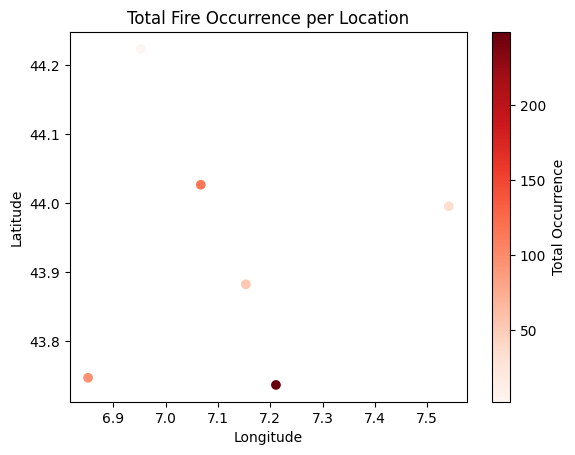

In [97]:
obj['date'] = pd.to_datetime(obj["date"])
occ = obj['occurence_scale'].sum(dim='date')

plt.scatter(obj['longitude'], obj['latitude'], c=occ, cmap='Reds')
plt.colorbar(label='Total Occurrence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Total Fire Occurrence per Location')
plt.show()

In [70]:
obj['occurence'].sum(dim=['id'])

<xarray.DataArray 'occurence' (date: 2394)>
array([0.       , 0.0075188, 0.       , ..., 0.       , 0.       ,
       0.       ])
Coordinates:
    departement  <U30 'departement-06-alpes-maritimes'
  * date         (date) datetime64[ns] 2017-06-12 2017-06-13 ... 2023-12-31

In [56]:
obj['latitude']

<xarray.DataArray 'latitude' (id: 6, date: 2394)>
array([[44.02648568, 44.02648568, 44.02648568, ..., 44.02648568,
        44.02648568, 44.02648568],
       [43.99540404, 43.99540404, 43.99540404, ..., 43.99540404,
        43.99540404, 43.99540404],
       [43.73639036, 43.73639036, 43.73639036, ..., 43.73639036,
        43.73639036, 43.73639036],
       [43.74675091, 43.74675091, 43.74675091, ..., 43.74675091,
        43.74675091, 43.74675091],
       [43.88223499, 43.88223499, 43.88223499, ..., 43.88223499,
        43.88223499, 43.88223499],
       [44.22333608, 44.22333608, 44.22333608, ..., 44.22333608,
        44.22333608, 44.22333608]])
Coordinates:
    departement  <U30 'departement-06-alpes-maritimes'
  * area         (id) float64 0.0 1.0 2.0 3.0 4.0 5.0
  * date         (date) datetime64[ns] 2017-06-12 2017-06-13 ... 2023-12-31
    graph_id     (id) float64 0.0 1.0 2.0 3.0 4.0 5.0
Dimensions without coordinates: id

In [99]:
df = obj.to_dataframe().reset_index()

In [ ]:
np.isnan(df['temp16_max'].values)

array([False, False, False, ..., False, False, False])

In [107]:
df['cluster_encoder']

KeyError: 'cluster_encoder'

In [48]:
np.all(df.area == df.graph_id)

True